# Estimating the fire model parameters with Gradient Descent

The goal of this Notebook is to show how Gradient desecnt can be used to estimate the true parameters of a fire.

We will need the following imports:

In [ ]:
import json
from pathlib import Path
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../"))
from simulators.CA_modified import CellularAutomaton_humidity_age #true (hard) CA
from simulators.model_solver import SoftFireCA, fit, plot_results, combined_loss, masked_mse #soft CA
from simulators.metrics import FireMetrics #compute metrics

The main idea is to approximate the true hard CA by a soft CA on which we can run gradient descent for the fire parameters.

If you haven't done it yet, generate a fire dataset using the "synthetic_data.ipynb" Notebook.

In [2]:
DATASET_DIR = Path("synthetic_fire_dataset")

env = np.load(DATASET_DIR / "common_maps.npz")
height_grid = env["height_grid"]
age_grid = env["age_grid"]
moisture_grid = env["moisture_grid"]

with open(DATASET_DIR / "dataset_index.json", "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

with open(DATASET_DIR / "config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

H = config["H"]
W = config["W"]
N_STEPS = config["N_STEPS"]
N_FIRES = config["N_FIRES"]
N_FIRES = 20
ALPHA = config["alpha"]
BETA = config["beta"]
GAMMA = config["gamma"]

fire_paths = [
    DATASET_DIR / item["file"]
    for item in dataset_index[:N_FIRES]
]

The parameters that we want to estimate here are ALPHA, BETA and GAMMA

In [3]:
# load the fire files
fires_data = []
for i in fire_paths:
    fire = np.load(i)
    fires_data.append({
        "ignition_point": fire["ignition_point"],
        "arrival_time":   fire["arrival_time"],
        "wind_grid":     fire["wind_grid"]
        })

# generate a model with the initial fire

model = SoftFireCA(
    height_grid, age_grid, moisture_grid,
    alpha_init=0.8, beta_init=0.8, gamma_init=0.8, 
)

print(f"Initial:  α={model.alpha.item():.3f}  β={model.beta.item():.3f}  γ={model.gamma.item():.3f}")
print(f"Target:   α={ALPHA}  β={BETA}  γ={GAMMA}\n")

# fit
history = fit(model, fires_data, n_steps=N_STEPS, n_epochs=100, lr=0.08)

print(f"\nRecovered:  α={model.alpha.item():.3f}  "
        f"β={model.beta.item():.3f}  γ={model.gamma.item():.3f}")
print(f"True:       α={ALPHA}  β={BETA}  γ={GAMMA}")

# plot
plot_results(history, ALPHA, BETA, GAMMA)

Initial:  α=0.800  β=0.800  γ=0.800
Target:   α=2.0  β=2.0  γ=1.2

Epoch    0  loss=0.03242  α=0.867  β=0.867  γ=0.738
Epoch   10  loss=0.00506  α=1.927  β=1.925  γ=0.353
Epoch   20  loss=0.00793  α=2.450  β=2.280  γ=0.274
Epoch   30  loss=0.00407  α=1.990  β=1.774  γ=0.288
Epoch   40  loss=0.00323  α=2.162  β=1.926  γ=0.281
Epoch   50  loss=0.00339  α=2.183  β=2.015  γ=0.284
Epoch   60  loss=0.00317  α=2.056  β=1.960  γ=0.296
Epoch   70  loss=0.00318  α=2.033  β=1.958  γ=0.304
Epoch   80  loss=0.00317  α=2.045  β=1.972  γ=0.307
Epoch   90  loss=0.00317  α=2.050  β=1.977  γ=0.309
Epoch   99  loss=0.00317  α=2.051  β=1.978  γ=0.309

Recovered:  α=2.051  β=1.978  γ=0.309
True:       α=2.0  β=2.0  γ=1.2


/Users/gillesfevry/Desktop/interractions/interactions/simulators/model_solver.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Plot saved to recovery_plot.png


To know if our loss has converged, we can compare it to the the loss induced by the approximation of the hard CA by the soft CA.

In [ ]:
model_soft = SoftFireCA(height_grid, age_grid, moisture_grid,
                         alpha_init=2.0, beta_init=2.0, gamma_init=1.2)
for p in model_soft.parameters():
    p.requires_grad_(False)

fires_data = []
for i in fire_paths:
    fire = np.load(i)
    fires_data.append({
        "ignition_point": fire["ignition_point"],
        "arrival_time":   fire["arrival_time"],
        "wind_grid":     fire["wind_grid"]
        })

loss = 0 

for fire in fires_data:
    wind = torch.tensor(fire["wind_grid"], dtype=torch.float32)
    obs  = torch.tensor(fire["arrival_time"], dtype=torch.float32)

    with torch.no_grad():
        pred = model_soft(fire["ignition_point"], wind, N_STEPS)
        loss += masked_mse(pred, obs, N_STEPS).item()

print("Approximation loss :", loss/len(fire_paths))

Approximation loss : 0.003140350730973296


For the synthetic dataset, they are very close

We can further investigate the losses and approximations we obtained by looking at the evolution the losses at each time step.

In [5]:
def make_phi(gamma):
    def phi(delta_h):
        if delta_h <= 0:
            return np.exp(gamma * delta_h)
        else:
            return 1.0 + gamma * np.sqrt(delta_h)
    return phi

def make_psi(beta):
    def psi(m):
        return np.exp(-beta * m)
    return psi

In [6]:
def get_states(fire, alpha, beta, gamma):

    CA = CellularAutomaton_humidity_age(
        grid_height = H,
        grid_width = W,
        wind_grid = fire["wind_grid"],
        age_grid= age_grid,
        height_grid=height_grid,
        moisture_grid= moisture_grid,
        phi = make_phi(gamma),
        psi = make_psi(beta),
        alpha_age = alpha,
        t_max = N_STEPS,
        )
    i0, j0 = fire["ignition_point"]
    CA.initialize_ignition([(int(i0), int(j0))], [0.8])
    CA_states = [CA.state_grid]
    for _ in range(N_STEPS):
        CA.evolve()
        CA_states.append(CA.state_grid)
    return CA_states
    
true_fire_states=[]
estimated_fire_states=[]
for fire in fires_data :
    true_fire_states.append(get_states(fire, ALPHA, BETA, GAMMA))
    estimated_fire_states.append(get_states(fire, model.alpha.item(), model.beta.item(), model.gamma.item()))

In [7]:
results = []
for i in range(len(true_fire_states)):
    FM = FireMetrics(true_fire_states[i], estimated_fire_states[i])
    result = [FM.all_shape_metrics(t,t) for t in range(N_STEPS)]
    results.append(result)

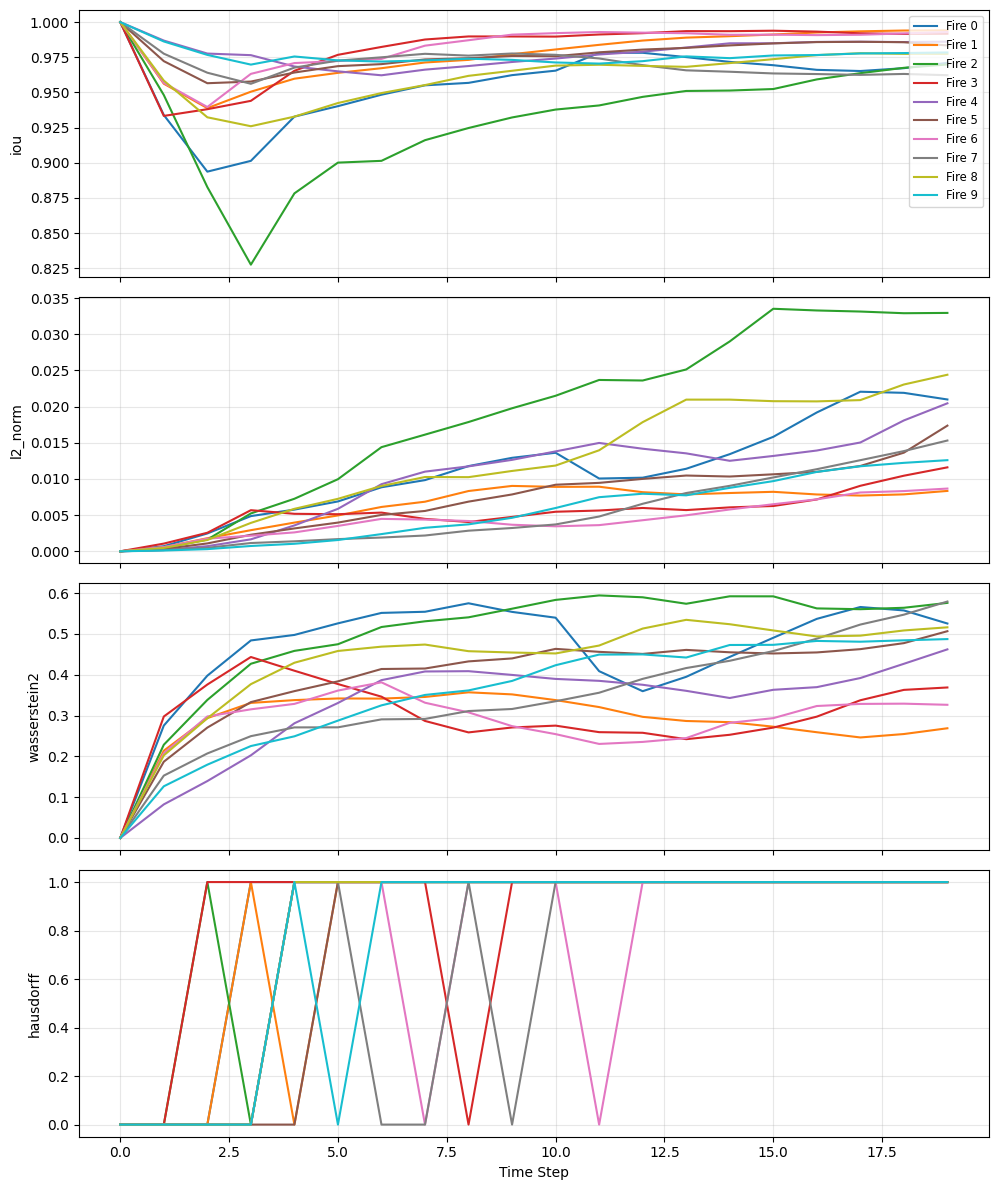

In [9]:
num_fires = 10
metric_names = list(results[0][0].keys())
num_metrics = len(metric_names)

fig, axes = plt.subplots(num_metrics, 1, figsize=(10, 3 * num_metrics), sharex=True)
if num_metrics == 1: axes = [axes]

for ax, metric in zip(axes, metric_names):
    for f_idx in range(num_fires):
        values = [step[metric] for step in results[f_idx]]
        ax.plot(values, label=f"Fire {f_idx}")
    
    ax.set_ylabel(metric)
    if ax == axes[0]:
        ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, alpha=0.3)

plt.xlabel("Time Step")
plt.tight_layout()
plt.show()